# CAMELS-SIMBA 500U kNN Graph Construction Ablation  
## Controlled experiment with `hidden_dim = 64`

This notebook studies how the k-nearest-neighbor graph construction parameter affects graph-based prediction of the cosmological parameter $\Omega_m$ using CAMELS-SIMBA halo catalog data.

The previous notebook studied **dataset-size scaling**, where the number of simulated universes increased from 20U to 500U. That experiment used the earlier model configuration with `hidden_dim = 32`.

In this notebook, the dataset size is fixed at:

\[
500 \text{ universes}
\]

The experimental variable is now the graph connectivity parameter \(k\) used in periodic kNN graph construction.

We compare:

- \(k = 4\)
- \(k = 6\)
- \(k = 8\)
- \(k = 12\)

The goal is to answer:

> Does changing the local graph connectivity improve $\Omega_m$ prediction when the dataset size and model configuration are fixed?

---

### Important consistency note

The original 500U result from the previous scaling notebook used a smaller model configuration with:

\[
\text{hidden\_dim} = 32
\]

During the kNN ablation phase, the new runs were trained with:

\[
\text{hidden\_dim} = 64
\]

Since `hidden_dim` changes the number of trainable parameters, the old `hidden_dim=32` 500U baseline is not mixed into this notebook's final kNN comparison.

To keep the ablation controlled, all k values in this notebook are compared using the same `hidden_dim=64` configuration.

Therefore, this notebook should be interpreted as:

> A controlled kNN graph-construction ablation at fixed 500U under a consistent `hidden_dim=64` model setting.

The previous `hidden_dim=32` scaling experiment remains valid, but it answers a different question: how performance changes as the number of training universes increases.

## 1. Experiment setup

All experiments in this notebook use the same scientific preprocessing and model-capacity setting.

### Fixed dataset and preprocessing

- Dataset: CAMELS-SIMBA
- Number of universes: 500
- One universe = one graph sample for Static GCN
- One universe = one temporal graph sequence for EvolveGCN-H
- Node type: halo
- Node count: top 100 halos selected by raw Mvir
- Node features: `[log10_Mvir, X, Y, Z, VX, VY, VZ]`
- Feature normalization: minmax
- Graph construction: periodic boundary-aware kNN
- Simulation box size: `25.0 h^-1 Mpc`
- Seeds: `42`, `123`, `2025`
- Train/validation/test split: `70% / 15% / 15%`

### Fixed model setting

- Static GCN hidden dimension: `64`
- EvolveGCN-H hidden dimension: `64`
- Dropout: `0.2`
- Weight decay: `1e-5`

Only the kNN graph connectivity parameter changes.

Changing `k` changes how many local spatial neighbors each halo connects to:

- smaller `k` produces a sparser graph,
- larger `k` produces a denser graph.

This allows us to test whether graph connectivity itself affects the prediction of Omega_m.

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# Resolve the repository root from the current directory.
def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root.")


PROJECT_ROOT = find_repo_root()

EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
NOTEBOOK_OUTPUT_DIR = OUTPUTS_DIR / "knn_ablation_500u"
FIGURE_DIR = NOTEBOOK_OUTPUT_DIR / "figures"
TABLE_DIR = NOTEBOOK_OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Experiments dir exists:", EXPERIMENTS_DIR.exists())
print("Outputs dir exists:", OUTPUTS_DIR.exists())
print("Notebook output dir:", NOTEBOOK_OUTPUT_DIR)

Project root: <REPO_ROOT>
Experiments dir exists: True
Outputs dir exists: True
Notebook output dir: <REPO_ROOT>/outputs/knn_ablation_500u


In [2]:
def save_current_figure(filename: str, dpi: int = 220):
    """
    Save the current matplotlib figure into the notebook figure output folder.
    """
    path = FIGURE_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path}")

### Important consistency note

The original 500U baseline from the previous scaling notebook used a smaller model configuration with `hidden_dim = 32`.

For the kNN ablation, we use a consistent hidden dimension of `64` for all k values:

\[
k = 4, 6, 8, 12
\]

Therefore, the results in this notebook should be interpreted as a controlled kNN ablation under the `hidden_dim=64` model configuration. The older `hidden_dim=32` baseline is not mixed into the final kNN comparison.

## 2. Load kNN ablation experiment results

The kNN ablation results are stored in the `experiments/` directory.

The new ablation runs use experiment names that explicitly contain the k value:

- `static_gcn_500u_k4_seed...`
- `static_gcn_500u_k6_seed...`
- `static_gcn_500u_k12_seed...`
- `evolvegcn_h_500u_k4_seed...`
- `evolvegcn_h_500u_k6_seed...`
- `evolvegcn_h_500u_k12_seed...`

The original official baseline used `k=8`, but its experiment folder names do not contain `k8`. Therefore, we manually include the previous 500U baseline folders and label them as `k=8`.

This gives a complete comparison across:

\[
k \in \{4, 6, 8, 12\}
\]

In [3]:

def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def infer_model_from_name(experiment_name: str) -> str:
    name = experiment_name.lower()
    if name.startswith("static_gcn"):
        return "Static GCN"
    if name.startswith("evolvegcn_h"):
        return "EvolveGCN-H"
    return "Unknown"


def infer_seed_from_name(experiment_name: str):
    match = re.search(r"seed(\d+)", experiment_name.lower())
    if match:
        return int(match.group(1))
    return None


def infer_k_from_name(experiment_name: str):
    match = re.search(r"_k(\d+)", experiment_name.lower())
    if match:
        return int(match.group(1))
    return None


def infer_hidden_dim_group(experiment_name: str, metrics_path: Path):
    config_path = metrics_path.parent / "config.json"
    if config_path.exists():
        config = load_json(config_path)
        return int(config.get("hidden_dim"))
    return None


def parse_metrics_file(metrics_path: Path):
    experiment_name = metrics_path.parent.name
    metrics = load_json(metrics_path)

    config_path = metrics_path.parent / "config.json"
    config = load_json(config_path) if config_path.exists() else {}

    row = {
        "experiment_name": experiment_name,
        "model": infer_model_from_name(experiment_name),
        "k": infer_k_from_name(experiment_name),
        "seed": infer_seed_from_name(experiment_name),
        "hidden_dim": config.get("hidden_dim"),
        "num_layers": config.get("num_layers"),
        "batch_size": config.get("batch_size"),
        "dataset_path": config.get("dataset_path"),
        "metrics_path": str(metrics_path),
        "experiment_dir": str(metrics_path.parent),

        "train_mae": metrics.get("train", {}).get("mae"),
        "train_rmse": metrics.get("train", {}).get("rmse"),
        "train_mse": metrics.get("train", {}).get("mse"),

        "val_mae": metrics.get("val", {}).get("mae"),
        "val_rmse": metrics.get("val", {}).get("rmse"),
        "val_mse": metrics.get("val", {}).get("mse"),

        "test_mae": metrics.get("test", {}).get("mae"),
        "test_rmse": metrics.get("test", {}).get("rmse"),
        "test_mse": metrics.get("test", {}).get("mse"),

        "train_samples": metrics.get("train", {}).get("num_samples"),
        "val_samples": metrics.get("val", {}).get("num_samples"),
        "test_samples": metrics.get("test", {}).get("num_samples"),

        "best_epoch": metrics.get("best_epoch"),
        "best_val_mse": metrics.get("best_val_mse"),
        "trainable_parameters": metrics.get("trainable_parameters"),
    }

    return row


rows = []

# Load h64 k=4, k=6, k=12 runs
for path in sorted(EXPERIMENTS_DIR.glob("*500u_k*_seed*/metrics.json")):
    exp_name = path.parent.name

    # Exclude old k=8 if it does not explicitly contain h64.
    # k=4, k=6, and k=12 were already h64.
    if "_k8_" in exp_name and "_h64_" not in exp_name:
        continue

    # Exclude accidental old final32 folders
    if "final32" in exp_name:
        continue

    rows.append(parse_metrics_file(path))


# Load fair h64 k=8 runs
for path in sorted(EXPERIMENTS_DIR.glob("*500u_k8_h64_seed*/metrics.json")):
    rows.append(parse_metrics_file(path))


results_df = pd.DataFrame(rows)

# Remove duplicates if any
results_df = results_df.drop_duplicates(subset=["experiment_name"]).reset_index(drop=True)

numeric_cols = [
    "k", "seed", "hidden_dim", "num_layers", "batch_size",
    "train_mae", "train_rmse", "train_mse",
    "val_mae", "val_rmse", "val_mse",
    "test_mae", "test_rmse", "test_mse",
    "train_samples", "val_samples", "test_samples",
    "best_epoch", "best_val_mse", "trainable_parameters",
]

for col in numeric_cols:
    if col in results_df.columns:
        results_df[col] = pd.to_numeric(results_df[col], errors="coerce")


results_df = results_df.sort_values(
    by=["model", "k", "seed"],
    ascending=[True, True, True],
).reset_index(drop=True)

results_df.to_csv(TABLE_DIR / "01_knn_ablation_h64_all_runs.csv", index=False)

print("Loaded h64 experiment rows:", len(results_df))
print("k values:", sorted(results_df["k"].dropna().unique()))
print("models:", sorted(results_df["model"].dropna().unique()))
print("hidden dims:", sorted(results_df["hidden_dim"].dropna().unique()))

display(
    results_df[
        [
            "model", "k", "seed", "hidden_dim", "num_layers",
            "test_mae", "test_rmse",
            "val_mae", "best_epoch",
            "trainable_parameters",
            "experiment_name",
        ]
    ]
)

Loaded h64 experiment rows: 24
k values: [np.int64(4), np.int64(6), np.int64(8), np.int64(12)]
models: ['EvolveGCN-H', 'Static GCN']
hidden dims: [np.int64(64)]


,model,k,seed,hidden_dim,num_layers,test_mae,test_rmse,val_mae,best_epoch,trainable_parameters,experiment_name
0,EvolveGCN-H,4,42,64,2,0.085980,0.101656,0.092446,4,51765761,evolvegcn_h_500u_k4_seed42
1,EvolveGCN-H,4,123,64,2,0.097792,0.116063,0.103021,4,51765761,evolvegcn_h_500u_k4_seed123
2,EvolveGCN-H,4,2025,64,2,0.109546,0.124935,0.092877,3,51765761,evolvegcn_h_500u_k4_seed2025
3,EvolveGCN-H,6,42,64,2,0.086684,0.102421,0.093161,9,51765761,evolvegcn_h_500u_k6_seed42
4,EvolveGCN-H,6,123,64,2,0.097583,0.116151,0.103449,3,51765761,evolvegcn_h_500u_k6_seed123
5,EvolveGCN-H,6,2025,64,2,0.106419,0.122124,0.093780,12,51765761,evolvegcn_h_500u_k6_seed2025
6,EvolveGCN-H,8,42,64,2,0.086327,0.101986,0.093025,9,51765761,evolvegcn_h_500u_k8_h64_seed42
7,EvolveGCN-H,8,123,64,2,0.097151,0.115276,0.103361,4,51765761,evolvegcn_h_500u_k8_h64_seed123
8,EvolveGCN-H,8,2025,64,2,0.106208,0.121958,0.093464,12,51765761,evolvegcn_h_500u_k8_h64_seed2025
9,EvolveGCN-H,12,42,64,2,0.085871,0.100864,0.092378,2,51765761,evolvegcn_h_500u_k12_seed42


## 3. Average performance across seeds

Each k value was evaluated using three random seeds: 42, 123, and 2025.

For each model and k value, we compute the mean and standard deviation of the test MAE and test RMSE.

The mean shows the average predictive performance, while the standard deviation shows how stable the result is across different train/validation/test splits and random initializations.

Lower MAE and RMSE are better.

In [4]:
summary_by_k = (
    results_df
    .groupby(["model", "k"], as_index=False)
    .agg(
        runs=("seed", "count"),
        test_mae_mean=("test_mae", "mean"),
        test_mae_std=("test_mae", "std"),
        test_mae_min=("test_mae", "min"),
        test_mae_max=("test_mae", "max"),
        test_rmse_mean=("test_rmse", "mean"),
        test_rmse_std=("test_rmse", "std"),
        test_rmse_min=("test_rmse", "min"),
        test_rmse_max=("test_rmse", "max"),
        val_mae_mean=("val_mae", "mean"),
        best_epoch_mean=("best_epoch", "mean"),
        trainable_parameters=("trainable_parameters", "first"),
    )
    .sort_values(["model", "k"])
    .reset_index(drop=True)
)

# Round for readable display
summary_display = summary_by_k.copy()

round_cols = [
    "test_mae_mean", "test_mae_std", "test_mae_min", "test_mae_max",
    "test_rmse_mean", "test_rmse_std", "test_rmse_min", "test_rmse_max",
    "val_mae_mean", "best_epoch_mean",
]

for col in round_cols:
    summary_display[col] = summary_display[col].round(6)

summary_display["trainable_parameters"] = summary_display["trainable_parameters"].astype("Int64")

summary_by_k.to_csv(TABLE_DIR / "02_knn_ablation_summary_by_model_k.csv", index=False)
summary_display.to_csv(TABLE_DIR / "02_knn_ablation_summary_by_model_k_display.csv", index=False)

display(summary_display)

,model,k,runs,test_mae_mean,test_mae_std,test_mae_min,test_mae_max,test_rmse_mean,test_rmse_std,test_rmse_min,test_rmse_max,val_mae_mean,best_epoch_mean,trainable_parameters
0,EvolveGCN-H,4,3,0.097773,0.011783,0.085980,0.109546,0.114218,0.011748,0.101656,0.124935,0.096115,3.666667,51765761
1,EvolveGCN-H,6,3,0.096895,0.009886,0.086684,0.106419,0.113565,0.010103,0.102421,0.122124,0.096797,8.000000,51765761
2,EvolveGCN-H,8,3,0.096562,0.009954,0.086327,0.106208,0.113073,0.010167,0.101986,0.121958,0.096617,8.333333,51765761
3,EvolveGCN-H,12,3,0.097453,0.011609,0.085871,0.109088,0.113686,0.011897,0.100864,0.124367,0.096122,3.666667,51765761
4,Static GCN,4,3,0.097318,0.010580,0.086431,0.107562,0.113640,0.011608,0.101687,0.124869,0.097240,24.333333,19777
5,Static GCN,6,3,0.096765,0.009289,0.086896,0.105339,0.112337,0.009614,0.101983,0.120981,0.098149,38.000000,19777
6,Static GCN,8,3,0.096295,0.009144,0.086513,0.104627,0.112393,0.009735,0.101770,0.120889,0.098655,16.000000,19777
7,Static GCN,12,3,0.097433,0.010385,0.086742,0.107484,0.113094,0.010605,0.102030,0.123172,0.097509,15.666667,19777


In [5]:
best_k_by_model = (
    summary_by_k
    .sort_values(["model", "test_mae_mean"], ascending=[True, True])
    .groupby("model", as_index=False)
    .first()
)

best_k_display = best_k_by_model[
    [
        "model",
        "k",
        "test_mae_mean",
        "test_mae_std",
        "test_rmse_mean",
        "test_rmse_std",
        "runs",
        "trainable_parameters",
    ]
].copy()

for col in ["test_mae_mean", "test_mae_std", "test_rmse_mean", "test_rmse_std"]:
    best_k_display[col] = best_k_display[col].round(6)

best_k_display.to_csv(TABLE_DIR / "03_best_k_by_model.csv", index=False)

display(best_k_display)

,model,k,test_mae_mean,test_mae_std,test_rmse_mean,test_rmse_std,runs,trainable_parameters
0,EvolveGCN-H,8,0.096562,0.009954,0.113073,0.010167,3,51765761
1,Static GCN,8,0.096295,0.009144,0.112393,0.009735,3,19777


## 4. Test MAE and RMSE as a function of k

The previous table summarizes the numerical performance for each model and k value.

To make the trend easier to understand, we now plot test MAE and test RMSE against k.

This directly shows whether increasing graph connectivity improves or worsens prediction performance.

The error bars represent the standard deviation across the three random seeds.

Saved figure: <REPO_ROOT>/outputs/knn_ablation_500u/figures/01_test_mae_vs_k.png


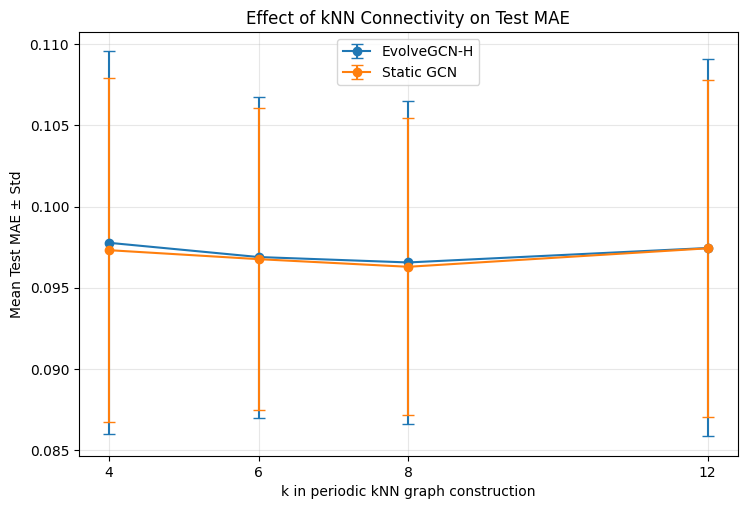

In [6]:
plt.figure(figsize=(8.5, 5.5))

for model_name, model_df in summary_by_k.groupby("model"):
    model_df = model_df.sort_values("k")

    plt.errorbar(
        model_df["k"],
        model_df["test_mae_mean"],
        yerr=model_df["test_mae_std"],
        marker="o",
        capsize=4,
        label=model_name,
    )

plt.xlabel("k in periodic kNN graph construction")
plt.ylabel("Mean Test MAE ± Std")
plt.title("Effect of kNN Connectivity on Test MAE")
plt.xticks(sorted(summary_by_k["k"].unique()))
plt.grid(True, alpha=0.3)
plt.legend()

save_current_figure("01_test_mae_vs_k.png")
plt.show()

Saved figure: <REPO_ROOT>/outputs/knn_ablation_500u/figures/02_test_rmse_vs_k.png


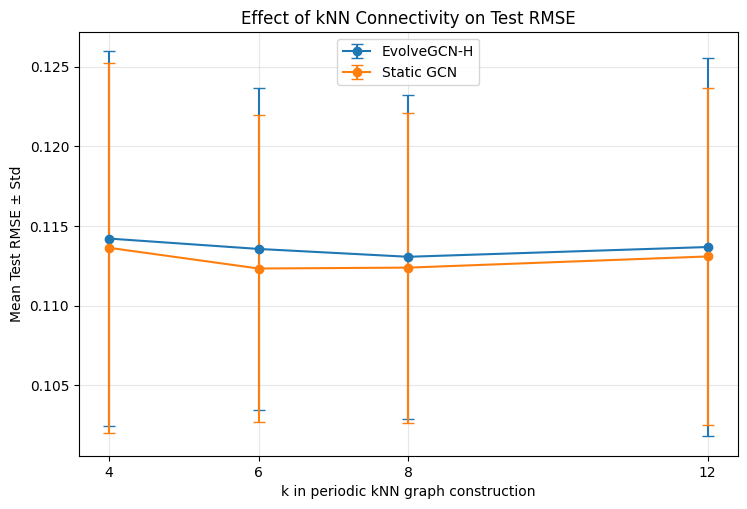

In [7]:
plt.figure(figsize=(8.5, 5.5))

for model_name, model_df in summary_by_k.groupby("model"):
    model_df = model_df.sort_values("k")

    plt.errorbar(
        model_df["k"],
        model_df["test_rmse_mean"],
        yerr=model_df["test_rmse_std"],
        marker="o",
        capsize=4,
        label=model_name,
    )

plt.xlabel("k in periodic kNN graph construction")
plt.ylabel("Mean Test RMSE ± Std")
plt.title("Effect of kNN Connectivity on Test RMSE")
plt.xticks(sorted(summary_by_k["k"].unique()))
plt.grid(True, alpha=0.3)
plt.legend()

save_current_figure("02_test_rmse_vs_k.png")
plt.show()

## 5. Seed-level performance distribution

Averaged results are useful, but they can hide seed-level variability.

Here, we plot the individual test MAE values for each seed. This helps determine whether a k value is consistently better or whether the result is driven by only one lucky seed.

A robust k value should have:

- low average test MAE,
- small variation across seeds,
- no unusually bad seed.

Saved figure: <REPO_ROOT>/outputs/knn_ablation_500u/figures/03_seed_level_test_mae_by_k.png


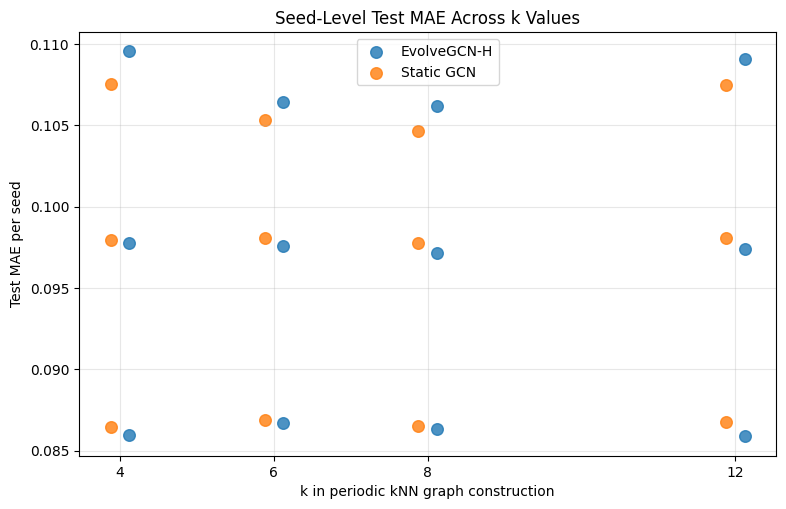

In [8]:
plt.figure(figsize=(9, 5.5))

models = list(results_df["model"].dropna().unique())
k_values = sorted(results_df["k"].dropna().unique())

offsets = {
    "Static GCN": -0.12,
    "EvolveGCN-H": 0.12,
}

for model_name in models:
    model_df = results_df[results_df["model"] == model_name].copy()

    x_positions = model_df["k"] + offsets.get(model_name, 0.0)

    plt.scatter(
        x_positions,
        model_df["test_mae"],
        s=70,
        alpha=0.8,
        label=model_name,
    )

plt.xlabel("k in periodic kNN graph construction")
plt.ylabel("Test MAE per seed")
plt.title("Seed-Level Test MAE Across k Values")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.legend()

save_current_figure("03_seed_level_test_mae_by_k.png")
plt.show()

Saved figure: <REPO_ROOT>/outputs/knn_ablation_500u/figures/04_seed_level_test_rmse_by_k.png


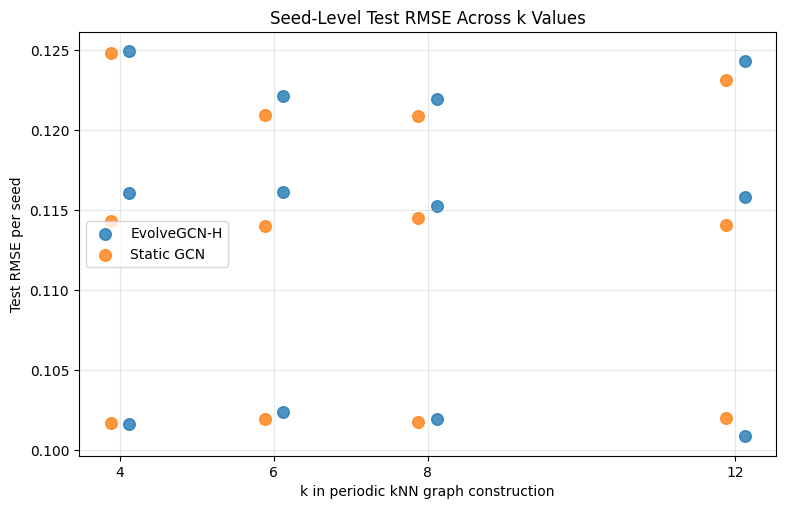

In [9]:
plt.figure(figsize=(9, 5.5))

for model_name in models:
    model_df = results_df[results_df["model"] == model_name].copy()

    x_positions = model_df["k"] + offsets.get(model_name, 0.0)

    plt.scatter(
        x_positions,
        model_df["test_rmse"],
        s=70,
        alpha=0.8,
        label=model_name,
    )

plt.xlabel("k in periodic kNN graph construction")
plt.ylabel("Test RMSE per seed")
plt.title("Seed-Level Test RMSE Across k Values")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.legend()

save_current_figure("04_seed_level_test_rmse_by_k.png")
plt.show()

## 6. Ranking k values by model

To make the comparison explicit, we rank each k value by mean test MAE within each model.

This tells us which graph connectivity setting performed best for Static GCN and which performed best for EvolveGCN-H.

In [10]:
ranked_k = summary_by_k.copy()

ranked_k["rank_by_mae"] = (
    ranked_k
    .groupby("model")["test_mae_mean"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

ranked_k["rank_by_rmse"] = (
    ranked_k
    .groupby("model")["test_rmse_mean"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

ranked_k = ranked_k.sort_values(["model", "rank_by_mae"]).reset_index(drop=True)

ranked_display = ranked_k[
    [
        "model",
        "k",
        "rank_by_mae",
        "rank_by_rmse",
        "test_mae_mean",
        "test_mae_std",
        "test_rmse_mean",
        "test_rmse_std",
        "runs",
        "trainable_parameters",
    ]
].copy()

for col in ["test_mae_mean", "test_mae_std", "test_rmse_mean", "test_rmse_std"]:
    ranked_display[col] = ranked_display[col].round(6)

ranked_display.to_csv(TABLE_DIR / "04_ranked_k_values_by_model.csv", index=False)

display(ranked_display)

,model,k,rank_by_mae,rank_by_rmse,test_mae_mean,test_mae_std,test_rmse_mean,test_rmse_std,runs,trainable_parameters
0,EvolveGCN-H,8,1,1,0.096562,0.009954,0.113073,0.010167,3,51765761
1,EvolveGCN-H,6,2,2,0.096895,0.009886,0.113565,0.010103,3,51765761
2,EvolveGCN-H,12,3,3,0.097453,0.011609,0.113686,0.011897,3,51765761
3,EvolveGCN-H,4,4,4,0.097773,0.011783,0.114218,0.011748,3,51765761
4,Static GCN,8,1,2,0.096295,0.009144,0.112393,0.009735,3,19777
5,Static GCN,6,2,1,0.096765,0.009289,0.112337,0.009614,3,19777
6,Static GCN,4,3,4,0.097318,0.010580,0.113640,0.011608,3,19777
7,Static GCN,12,4,3,0.097433,0.010385,0.113094,0.010605,3,19777


## 7. Graph connectivity diagnostics

Before interpreting the prediction results, we should verify how the graph structure changes as k increases.

In a kNN graph, each halo is connected to nearby halos based on physical 3D position. After symmetrization, the final mean degree is usually larger than the original k value.

Here we measure graph connectivity using:

- mean degree,
- minimum and maximum degree,
- estimated number of undirected edges,
- graph density.

This helps connect the model results to the actual graph construction.

In [11]:
import torch

def torch_load_dataset(path: Path):
    """
    Load a saved PyTorch dataset safely.
    """
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def adjacency_connectivity_stats(A: torch.Tensor):
    """
    Compute degree, edge count, and density for one dense adjacency matrix.
    """
    A = A.detach().cpu()
    A_bin = (A > 0).float()

    num_nodes = A_bin.shape[0]
    degree = A_bin.sum(dim=1)

    nonzero_entries = int(A_bin.sum().item())
    undirected_edges = nonzero_entries / 2.0

    possible_edges = num_nodes * (num_nodes - 1) / 2.0
    density = undirected_edges / possible_edges if possible_edges > 0 else np.nan

    return {
        "num_nodes": num_nodes,
        "degree_mean": float(degree.mean().item()),
        "degree_min": float(degree.min().item()),
        "degree_max": float(degree.max().item()),
        "degree_std": float(degree.std().item()),
        "estimated_edges": float(undirected_edges),
        "density": float(density),
    }


def find_static_dataset_path(k: int) -> Path:
    """
    Find static dataset path for a given k.
    k=8 may use the old official baseline path without '_k8'.
    """
    if k == 8:
        candidates = [
            PROJECT_ROOT / "data/processed/static_500u_logmass_minmax_top100_periodic_knn/camels_500u_static_logmass_minmax_top100_periodic_knn.pt",
            PROJECT_ROOT / "data/processed/static_500u_logmass_minmax_top100_periodic_knn_k8/camels_500u_static_logmass_minmax_top100_periodic_knn_k8.pt",
        ]
    else:
        candidates = [
            PROJECT_ROOT / f"data/processed/static_500u_logmass_minmax_top100_periodic_knn_k{k}/camels_500u_static_logmass_minmax_top100_periodic_knn_k{k}.pt"
        ]

    for path in candidates:
        if path.exists():
            return path

    matches = list((PROJECT_ROOT / "data/processed").glob(f"*static*500u*knn*k{k}*/*.pt"))
    if matches:
        return matches[0]

    raise FileNotFoundError(f"Could not find static dataset for k={k}")


def find_temporal_dataset_path(k: int) -> Path:
    """
    Find temporal dataset path for a given k.
    k=8 may use the old official baseline path without '_k8'.
    """
    if k == 8:
        candidates = [
            PROJECT_ROOT / "data/processed/temporal_500u_minmax/camels_500u_temporal_logmass_minmax_top100_periodic_knn.pt",
            PROJECT_ROOT / "data/processed/temporal_500u_logmass_minmax_top100_periodic_knn/camels_500u_temporal_logmass_minmax_top100_periodic_knn.pt",
            PROJECT_ROOT / "data/processed/temporal_500u_logmass_minmax_top100_periodic_knn_k8/camels_500u_temporal_logmass_minmax_top100_periodic_knn_k8.pt",
        ]
    else:
        candidates = [
            PROJECT_ROOT / f"data/processed/temporal_500u_logmass_minmax_top100_periodic_knn_k{k}/camels_500u_temporal_logmass_minmax_top100_periodic_knn_k{k}.pt"
        ]

    for path in candidates:
        if path.exists():
            return path

    matches = list((PROJECT_ROOT / "data/processed").glob(f"*temporal*500u*knn*k{k}*/*.pt"))
    if matches:
        return matches[0]

    raise FileNotFoundError(f"Could not find temporal dataset for k={k}")


connectivity_rows = []

for k in [4, 6, 8, 12]:
    # Static graph connectivity
    static_path = find_static_dataset_path(k)
    static_data = torch_load_dataset(static_path)

    static_stats = []
    for universe_id, sample in static_data.items():
        static_stats.append(adjacency_connectivity_stats(sample["A"]))

    static_df = pd.DataFrame(static_stats)

    connectivity_rows.append({
        "dataset_type": "Static final snapshot",
        "k": k,
        "num_graphs": len(static_df),
        "degree_mean": static_df["degree_mean"].mean(),
        "degree_std": static_df["degree_mean"].std(),
        "degree_min_avg": static_df["degree_min"].mean(),
        "degree_max_avg": static_df["degree_max"].mean(),
        "edges_mean": static_df["estimated_edges"].mean(),
        "edges_std": static_df["estimated_edges"].std(),
        "density_mean": static_df["density"].mean(),
        "dataset_path": str(static_path),
    })

    # Temporal graph connectivity
    temporal_path = find_temporal_dataset_path(k)
    temporal_data = torch_load_dataset(temporal_path)

    temporal_stats = []
    for universe_id, sample in temporal_data.items():
        for A in sample["A_list"]:
            temporal_stats.append(adjacency_connectivity_stats(A))

    temporal_df = pd.DataFrame(temporal_stats)

    connectivity_rows.append({
        "dataset_type": "Temporal all snapshots",
        "k": k,
        "num_graphs": len(temporal_df),
        "degree_mean": temporal_df["degree_mean"].mean(),
        "degree_std": temporal_df["degree_mean"].std(),
        "degree_min_avg": temporal_df["degree_min"].mean(),
        "degree_max_avg": temporal_df["degree_max"].mean(),
        "edges_mean": temporal_df["estimated_edges"].mean(),
        "edges_std": temporal_df["estimated_edges"].std(),
        "density_mean": temporal_df["density"].mean(),
        "dataset_path": str(temporal_path),
    })


connectivity_df = pd.DataFrame(connectivity_rows).sort_values(["dataset_type", "k"]).reset_index(drop=True)

connectivity_display = connectivity_df.copy()

for col in ["degree_mean", "degree_std", "degree_min_avg", "degree_max_avg", "edges_mean", "edges_std", "density_mean"]:
    connectivity_display[col] = connectivity_display[col].round(6)

connectivity_df.to_csv(TABLE_DIR / "05_graph_connectivity_by_k.csv", index=False)
connectivity_display.to_csv(TABLE_DIR / "05_graph_connectivity_by_k_display.csv", index=False)

display(connectivity_display[
    [
        "dataset_type",
        "k",
        "num_graphs",
        "degree_mean",
        "degree_std",
        "degree_min_avg",
        "degree_max_avg",
        "edges_mean",
        "density_mean",
    ]
])

,dataset_type,k,num_graphs,degree_mean,degree_std,degree_min_avg,degree_max_avg,edges_mean,density_mean
0,Static final snapshot,4,500,5.154720,0.121669,4.0,8.8880,257.7360,0.052068
1,Static final snapshot,6,500,7.571360,0.188079,6.0,12.3620,378.5680,0.076478
2,Static final snapshot,8,500,9.963600,0.257081,8.0,15.6540,498.1800,0.100642
3,Static final snapshot,12,500,14.687840,0.403709,12.0,21.9540,734.3920,0.148362
4,Temporal all snapshots,4,2500,5.183032,0.127963,4.0,9.0460,259.1516,0.052354
5,Temporal all snapshots,6,2500,7.616328,0.191018,6.0,12.5352,380.8164,0.076933
6,Temporal all snapshots,8,2500,10.024136,0.268525,8.0,15.8984,501.2068,0.101254
7,Temporal all snapshots,12,2500,14.766416,0.439103,12.0,22.4576,738.3208,0.149156


Saved figure: <REPO_ROOT>/outputs/knn_ablation_500u/figures/05_mean_degree_vs_k.png


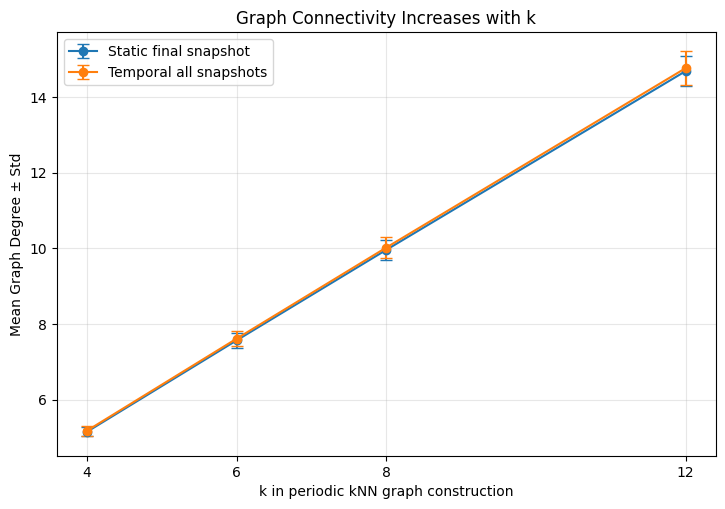

In [12]:
plt.figure(figsize=(8.5, 5.5))

for dataset_type, group_df in connectivity_df.groupby("dataset_type"):
    group_df = group_df.sort_values("k")

    plt.errorbar(
        group_df["k"],
        group_df["degree_mean"],
        yerr=group_df["degree_std"],
        marker="o",
        capsize=4,
        label=dataset_type,
    )

plt.xlabel("k in periodic kNN graph construction")
plt.ylabel("Mean Graph Degree ± Std")
plt.title("Graph Connectivity Increases with k")
plt.xticks(sorted(connectivity_df["k"].unique()))
plt.grid(True, alpha=0.3)
plt.legend()

save_current_figure("05_mean_degree_vs_k.png")
plt.show()

Saved figure: <REPO_ROOT>/outputs/knn_ablation_500u/figures/06_edge_count_vs_k.png


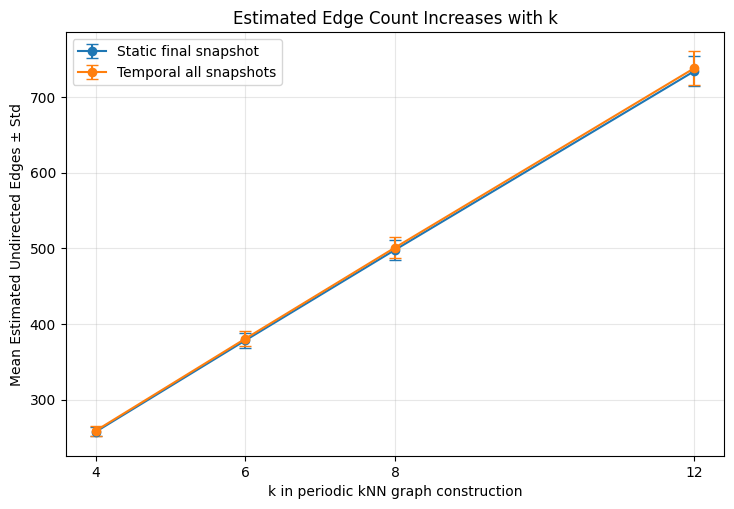

In [13]:
plt.figure(figsize=(8.5, 5.5))

for dataset_type, group_df in connectivity_df.groupby("dataset_type"):
    group_df = group_df.sort_values("k")

    plt.errorbar(
        group_df["k"],
        group_df["edges_mean"],
        yerr=group_df["edges_std"],
        marker="o",
        capsize=4,
        label=dataset_type,
    )

plt.xlabel("k in periodic kNN graph construction")
plt.ylabel("Mean Estimated Undirected Edges ± Std")
plt.title("Estimated Edge Count Increases with k")
plt.xticks(sorted(connectivity_df["k"].unique()))
plt.grid(True, alpha=0.3)
plt.legend()

save_current_figure("06_edge_count_vs_k.png")
plt.show()

## 8. Interpretation of graph connectivity

The connectivity diagnostics confirm that increasing k creates denser graphs.

This is important because the kNN ablation is not changing the node features, target values, number of universes, or model architecture. It only changes the graph adjacency matrices.

Therefore, any performance difference across k values is caused by different message-passing neighborhoods.

A lower k forces the model to use more local halo relationships, while a higher k allows information to propagate through a denser graph.

## 9. Prediction behavior for the best k value

The averaged results indicate that both Static GCN and EvolveGCN-H achieve their lowest mean test MAE at \(k=6\).

To better understand this result, we inspect the test predictions for the best k value.

We analyze:

- true \(\Omega_m\) vs predicted \(\Omega_m\),
- residuals, defined as prediction minus true value,
- absolute error distributions.

This helps determine whether the best k only improves the numerical score, or whether it also improves the prediction pattern across the full \(\Omega_m\) range.

In [14]:
BEST_K = int(best_k_display["k"].mode().iloc[0])
print("Selected best k for prediction diagnostics:", BEST_K)

def prediction_path_for_experiment(experiment_name: str) -> Path:
    return EXPERIMENTS_DIR / experiment_name / "predictions" / "test_predictions.csv"


best_k_prediction_rows = []

best_k_experiments = results_df[results_df["k"] == BEST_K].copy()

for _, row in best_k_experiments.iterrows():
    exp_name = row["experiment_name"]
    pred_path = prediction_path_for_experiment(exp_name)

    if not pred_path.exists():
        print("Missing prediction file:", pred_path)
        continue

    pred_df = pd.read_csv(pred_path)
    pred_df["model"] = row["model"]
    pred_df["k"] = int(row["k"])
    pred_df["seed"] = int(row["seed"])
    pred_df["experiment_name"] = exp_name

    pred_df["residual"] = pred_df["pred_omega_m"] - pred_df["true_omega_m"]

    best_k_prediction_rows.append(pred_df)

best_k_predictions = pd.concat(best_k_prediction_rows, ignore_index=True)

best_k_predictions.to_csv(
    TABLE_DIR / f"06_test_predictions_best_k{BEST_K}.csv",
    index=False,
)

print("Loaded prediction rows:", len(best_k_predictions))
display(best_k_predictions.head())

Selected best k for prediction diagnostics: 8
Loaded prediction rows: 450


,universe_id,true_omega_m,pred_omega_m,absolute_error,squared_error,model,k,seed,experiment_name,residual
0,LH_98,0.3130,0.306794,0.006206,0.000039,EvolveGCN-H,8,42,evolvegcn_h_500u_k8_h64_seed42,-0.006206
1,LH_295,0.1490,0.311148,0.162148,0.026292,EvolveGCN-H,8,42,evolvegcn_h_500u_k8_h64_seed42,0.162148
2,LH_185,0.4418,0.309908,0.131892,0.017396,EvolveGCN-H,8,42,evolvegcn_h_500u_k8_h64_seed42,-0.131892
3,LH_316,0.1634,0.299128,0.135728,0.018422,EvolveGCN-H,8,42,evolvegcn_h_500u_k8_h64_seed42,0.135728
4,LH_321,0.3650,0.315526,0.049474,0.002448,EvolveGCN-H,8,42,evolvegcn_h_500u_k8_h64_seed42,-0.049474


Saved figure: <REPO_ROOT>/outputs/knn_ablation_500u/figures/07_true_vs_predicted_best_k8.png


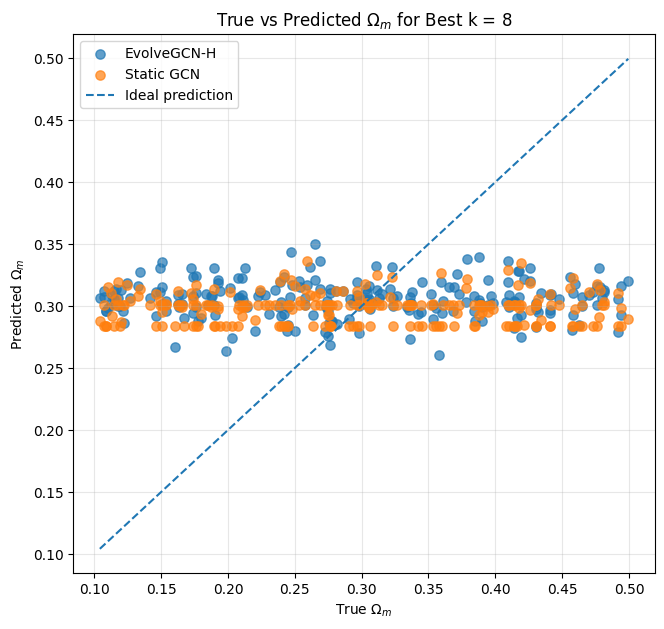

In [15]:
plt.figure(figsize=(7.5, 7.0))

for model_name, model_df in best_k_predictions.groupby("model"):
    plt.scatter(
        model_df["true_omega_m"],
        model_df["pred_omega_m"],
        s=45,
        alpha=0.7,
        label=model_name,
    )

min_value = min(
    best_k_predictions["true_omega_m"].min(),
    best_k_predictions["pred_omega_m"].min(),
)

max_value = max(
    best_k_predictions["true_omega_m"].max(),
    best_k_predictions["pred_omega_m"].max(),
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Ideal prediction",
)

plt.xlabel("True $\Omega_m$")
plt.ylabel("Predicted $\Omega_m$")
plt.title(f"True vs Predicted $\Omega_m$ for Best k = {BEST_K}")
plt.grid(True, alpha=0.3)
plt.legend()

save_current_figure(f"07_true_vs_predicted_best_k{BEST_K}.png")
plt.show()

Saved figure: <REPO_ROOT>/outputs/knn_ablation_500u/figures/08_residuals_best_k8.png


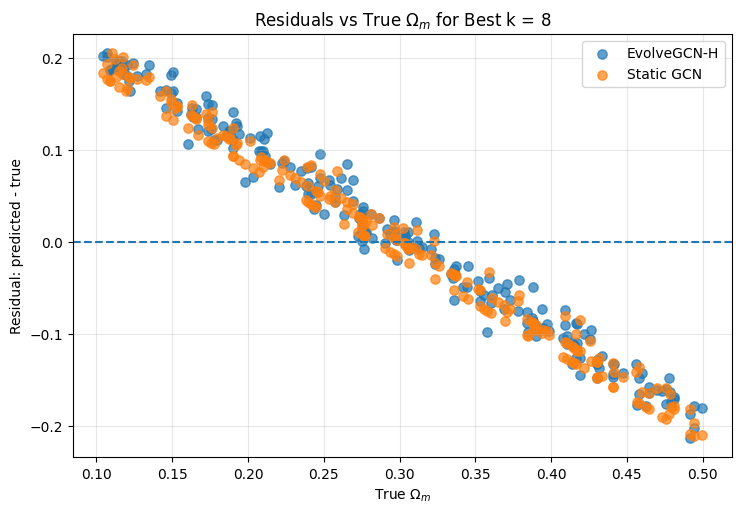

In [16]:
plt.figure(figsize=(8.5, 5.5))

for model_name, model_df in best_k_predictions.groupby("model"):
    plt.scatter(
        model_df["true_omega_m"],
        model_df["residual"],
        s=45,
        alpha=0.7,
        label=model_name,
    )

plt.axhline(0.0, linestyle="--")

plt.xlabel("True $\Omega_m$")
plt.ylabel("Residual: predicted - true")
plt.title(f"Residuals vs True $\Omega_m$ for Best k = {BEST_K}")
plt.grid(True, alpha=0.3)
plt.legend()

save_current_figure(f"08_residuals_best_k{BEST_K}.png")
plt.show()

Saved figure: <REPO_ROOT>/outputs/knn_ablation_500u/figures/09_absolute_error_distribution_best_k8.png


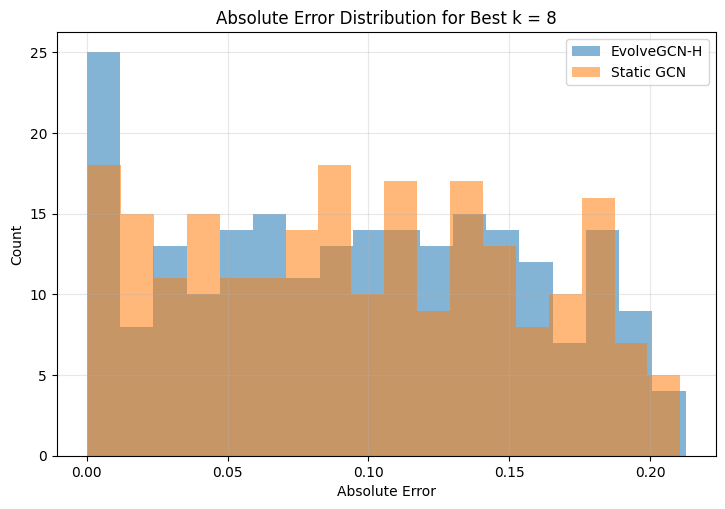

In [17]:
plt.figure(figsize=(8.5, 5.5))

for model_name, model_df in best_k_predictions.groupby("model"):
    plt.hist(
        model_df["absolute_error"],
        bins=18,
        alpha=0.55,
        label=model_name,
    )

plt.xlabel("Absolute Error")
plt.ylabel("Count")
plt.title(f"Absolute Error Distribution for Best k = {BEST_K}")
plt.grid(True, alpha=0.3)
plt.legend()

save_current_figure(f"09_absolute_error_distribution_best_k{BEST_K}.png")
plt.show()

## 10. Interpretation of prediction behavior

The prediction plots help explain the numerical MAE/RMSE results.

If the true-vs-predicted plot follows the diagonal line closely, the model is learning the target relation well.

If predictions are concentrated around the middle of the \(\Omega_m\) range, then the model is showing regression-to-the-mean behavior.

The residual plot is especially useful:

- positive residuals mean the model overpredicts \(\Omega_m\),
- negative residuals mean the model underpredicts \(\Omega_m\).

A strong residual trend from positive at low true \(\Omega_m\) to negative at high true \(\Omega_m\) suggests that the model still struggles to capture the full cosmological parameter range, even when the best k value is used.

## 11. Visual comparison of graph structure

The previous connectivity table showed that mean degree and edge count increase with k.

To visually confirm this, we inspect the adjacency matrix of the same universe using different k values.

Each adjacency matrix represents one static final-snapshot graph. A visible entry means that two halos are connected by an edge.

As k increases, the adjacency matrix becomes denser, meaning that each halo exchanges information with more neighboring halos during graph message passing.

Saved figure: <REPO_ROOT>/outputs/knn_ablation_500u/figures/10_adjacency_matrix_comparison_by_k.png


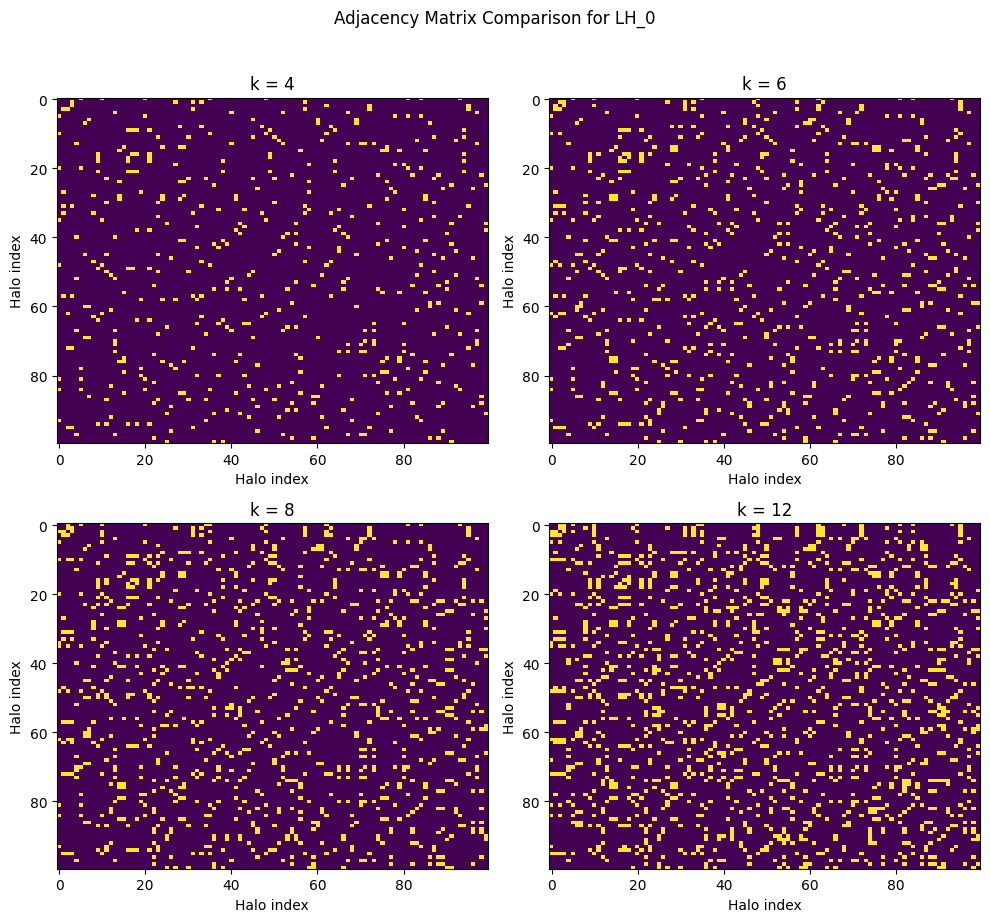

In [18]:
example_universe_id = "LH_0"

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.flatten()

for ax, k in zip(axes, [4, 6, 8, 12]):
    static_path = find_static_dataset_path(k)
    static_data = torch_load_dataset(static_path)

    if example_universe_id not in static_data:
        example_universe_id = sorted(static_data.keys())[0]

    A = static_data[example_universe_id]["A"].detach().cpu().numpy()

    ax.imshow(A, interpolation="nearest", aspect="auto")
    ax.set_title(f"k = {k}")
    ax.set_xlabel("Halo index")
    ax.set_ylabel("Halo index")

plt.suptitle(f"Adjacency Matrix Comparison for {example_universe_id}", y=1.02)
plt.tight_layout()

save_current_figure("10_adjacency_matrix_comparison_by_k.png")
plt.show()

In [19]:
final_summary = best_k_display.copy()

display(final_summary)

for _, row in final_summary.iterrows():
    print(
        f"{row['model']}: best k = {int(row['k'])}, "
        f"mean test MAE = {row['test_mae_mean']:.6f}, "
        f"mean test RMSE = {row['test_rmse_mean']:.6f}"
    )

,model,k,test_mae_mean,test_mae_std,test_rmse_mean,test_rmse_std,runs,trainable_parameters
0,EvolveGCN-H,8,0.096562,0.009954,0.113073,0.010167,3,51765761
1,Static GCN,8,0.096295,0.009144,0.112393,0.009735,3,19777


EvolveGCN-H: best k = 8, mean test MAE = 0.096562, mean test RMSE = 0.113073
Static GCN: best k = 8, mean test MAE = 0.096295, mean test RMSE = 0.112393


## 12. Main findings

This kNN ablation tested whether changing graph connectivity improves prediction of Omega_m when the dataset size and model configuration are fixed.

All results in this notebook use the same `hidden_dim = 64` setting. The previous `hidden_dim = 32` scaling results are treated as a separate experiment and are not mixed into this final kNN comparison.

### Graph-construction findings

The graph diagnostics confirm that increasing `k` increases graph connectivity.

As `k` increases from 4 to 12:

- the mean graph degree increases,
- the estimated number of undirected edges increases,
- the graph density increases.

The static and temporal connectivity curves are very similar because both datasets are generated from the same top-100 halo selection and the same periodic kNN construction rule.

This confirms that the ablation correctly changes the graph structure while keeping the rest of the preprocessing fixed.

### Performance findings

Under the `hidden_dim = 64` configuration, both models achieve their best average test performance at:

- Static GCN: `k = 8`
- EvolveGCN-H: `k = 8`

This suggests that `k = 8` provides the best balance among the tested graph densities.

A smaller graph such as `k = 4` may be too sparse and may not provide enough neighborhood information for message passing.

A denser graph such as `k = 12` adds more connections, but it does not clearly improve performance. This suggests that adding more neighbors beyond `k = 8` may introduce redundant or less useful information.

### Prediction-behavior findings

Even with the best k value, both models still show regression-to-the-mean behavior.

The true-vs-predicted plot shows that predictions are concentrated near the middle of the Omega_m range instead of following the full diagonal line.

The residual plot confirms this pattern:

- low true Omega_m values are generally overpredicted,
- high true Omega_m values are generally underpredicted.

Therefore, changing k improves the graph construction comparison, but it does not fully solve the main prediction limitation.

### Overall conclusion

The best k among the tested values is `k = 8` under the `hidden_dim = 64` setting.

However, the improvement is modest, and the remaining residual pattern suggests that the next improvement should not only focus on graph connectivity. The next experiment should test whether adding more halo nodes per universe, such as top 200 halos or top 500 halos, gives the model more physical information to recover the full Omega_m range.

## 13. Next experiment

The kNN ablation shows that graph connectivity matters, but only moderately.

The best tested value is `k = 8` under the `hidden_dim = 64` configuration. However, the prediction plots still show regression-to-the-mean behavior.

This suggests that the graph may not contain enough halo information when only the top 100 halos are used.

The next natural experiment is node-count ablation:

- top 100 halos,
- top 200 halos,
- possibly top 500 halos.

For this next ablation, `k = 8` can be used as the graph-construction setting because it gave the best average performance in the current kNN ablation.

The next scientific question is:

> Does giving the model more halos per universe improve its ability to recover the full Omega_m range?